Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
............Model Loaded Successfully!.........................
Please upload an image for prediction:


Saving WhatsApp Image 2026-07-25 at 12.28.54 AM.jpeg to WhatsApp Image 2026-07-25 at 12.28.54 AM.jpeg
Prediction: dog


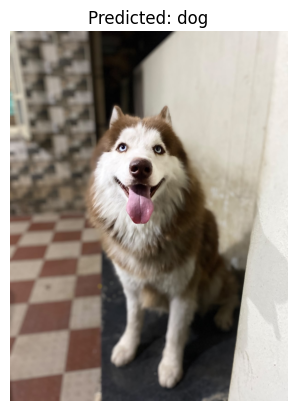

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
from PIL import Image
import os
from google.colab import drive
from google.colab import files


model = resnet18(weights=None)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)


drive.mount('/content/drive')
model_path = "/content/drive/MyDrive/my_resnet.pth"

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    model.eval()
    print("............Model Loaded Successfully!.........................")
else:
    print(f"Error: Model file not found at {model_path}")


print("Please upload an image for prediction:")
upload = files.upload()

if upload:
    image_path = next(iter(upload))
    image = Image.open(image_path).convert('RGB')

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    image_tensor = transform(image).unsqueeze(0)


    with torch.no_grad():
        output = model(image_tensor)

    prediction = torch.argmax(output, dim=1)
    classes = ["cat", "dog"]
    predicted_class = classes[prediction.item()]
    print(f"Prediction: {predicted_class}")


    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Predicted: {predicted_class}")
    plt.show()
else:
    print("No file uploaded.")